# Installations

In [1]:
! pip install sentence-transformers

# BGE-M3

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("BAAI/bge-m3")

sentences = [
    "That is a happy person",
    "That is a happy dog",
    "That is a very happy person",
    "Today is a sunny day"
]
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [4]:
print(embeddings)

[[-0.01178022  0.00884027 -0.05844677 ...  0.00750243 -0.04790135
   0.00330676]
 [-0.03470374 -0.00886353 -0.05242302 ...  0.00899352 -0.02396279
   0.02985834]
 [-0.01356587  0.01900947 -0.05800955 ...  0.00523863 -0.05689552
   0.00077098]
 [-0.02149694  0.02998875 -0.05638724 ...  0.01443706 -0.02131324
  -0.00112457]]


In [5]:
print(len(embeddings))

4


In [6]:
print(len(embeddings[0]))

1024


In [7]:
# sentences = [
#     "That is a happy person",
#     "That is a happy dog",
#     "That is a very happy person",
#     "Today is a sunny day"
# ]
similarities = model.similarity(embeddings, embeddings)
print(similarities)

tensor([[1.0000, 0.8589, 0.9666, 0.7510],
        [0.8589, 1.0000, 0.8252, 0.6802],
        [0.9666, 0.8252, 1.0000, 0.7296],
        [0.7510, 0.6802, 0.7296, 1.0000]])


# E5

In [8]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("intfloat/e5-large-v2")

sentences = [
    "That is a happy person",
    "That is a happy dog",
    "That is a very happy person",
    "Today is a sunny day"
]
embeddings = model.encode(sentences)

similarities = model.similarity(embeddings, embeddings)
print(similarities)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/67.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.34GB            

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

tensor([[1.0000, 0.9380, 0.9316, 0.8093],
        [0.9380, 1.0000, 0.8810, 0.7947],
        [0.9316, 0.8810, 1.0000, 0.7926],
        [0.8093, 0.7947, 0.7926, 1.0000]])


In [10]:
embeddings

array([[ 0.0127706 , -0.05978677,  0.03338464, ..., -0.02273697,
         0.02050192,  0.02209188],
       [ 0.0099377 , -0.04214675,  0.04332986, ..., -0.04515261,
         0.01464127,  0.04638134],
       [ 0.01309448, -0.06783762,  0.03781607, ..., -0.03237491,
         0.0286786 ,  0.02065299],
       [ 0.01029333, -0.07214311,  0.02413189, ..., -0.03575477,
         0.03678786,  0.04026351]], dtype=float32)

In [9]:
embedding_dimension = len(embeddings[0])
print(embedding_dimension)

1024


# INSTRUCTOR

In [12]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load the model directly using the modern library
model = SentenceTransformer('hkunlp/instructor-large')

# Format instructions manually by concatenating the string
corpus = [
    "Represent the Machine Learning syllabus: A foundational module on building deep neural networks and calculating backpropagation.",
    "Represent the Generative AI tutorial: A step-by-step guide to deploying RAG pipelines utilizing vector databases.",
    "Represent the MLOps documentation: Configuring automated workflow pipelines using GitHub Actions and Microsoft Azure."
]

query = ["Represent the query for retrieving technical AI training materials: How do I build a RAG architecture?"]

print("Generating embeddings...")
corpus_embeddings = model.encode(corpus)
query_embedding = model.encode(query)

similarities = model.similarity(query_embedding, corpus_embeddings)

print(similarities)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Generating embeddings...
tensor([[0.8527, 0.9141, 0.8301]])


# CLIP

#### Code to download Lenna image - IGNORE

In [ ]:
! pip install requests

Success! Image saved as 'lenna.png'



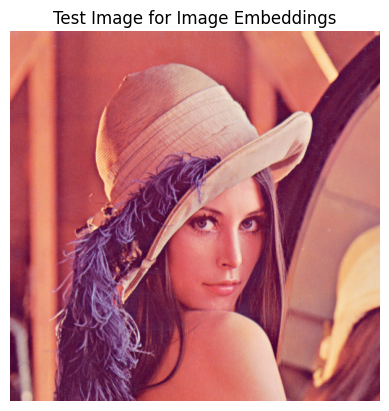

In [ ]:
import requests
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_url = 'https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png'

# The fix: Mimicking a real web browser to bypass the 403 block
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

print("Downloading image...")
image_response = requests.get(image_url, headers=headers)
image_response.raise_for_status()

# Save the image
save_path = "lenna.png"
with open(save_path, 'wb') as f:
    f.write(image_response.content)

print(f"Success! Image saved as '{save_path}'\n")

# --- Displaying the Image in Colab ---
img = mpimg.imread(save_path)
plt.imshow(img)
plt.title("Test Image for Image Embeddings")
plt.axis('off')
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer
from PIL import Image

# sentence-transformers natively supports CLIP for image embeddings
model = SentenceTransformer('clip-ViT-B-32')

image_path = "/content/lenna.png"
image = Image.open(image_path)

image_embedding = model.encode(image)
image_embedding

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

0_CLIPModel/model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

array([ 6.84102774e-02, -1.46617204e-01,  5.42101078e-02, -6.75082505e-02,
       -5.41782826e-02, -1.21572398e-01, -1.59910977e-01, -1.09142646e-01,
       -2.94246227e-01, -3.02379400e-01,  3.15435797e-01, -8.08410197e-02,
        5.43568373e-01, -6.49977848e-02,  5.78288376e-01, -3.61249506e-01,
        7.31827378e-01, -9.82108861e-02,  5.39652705e-01,  1.28879130e-01,
        3.80596459e-01, -3.07231367e-01, -8.69712234e-03, -6.79952279e-02,
       -5.63533902e-02, -4.89664078e-03, -1.76983804e-01,  1.93777516e-01,
       -1.92951813e-01,  4.35591757e-01, -3.74959409e-01,  2.48752087e-01,
       -3.03665400e-01, -1.07043982e-02, -4.57846075e-01, -2.46126920e-01,
       -9.12581161e-02,  5.77755213e-01,  1.79910719e-01,  2.06362700e+00,
       -3.95954847e-02, -8.31276178e-03, -4.91254210e-01, -5.31028688e-01,
        7.13604763e-02,  7.02695072e-01, -1.81001246e-01,  7.42043406e-02,
        1.18849576e-02,  3.46275508e-01,  2.00398728e-01, -1.25236377e-01,
        7.68825412e-03,  